In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import validation_curve

from sklearn.linear_model import SGDRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
np.random.seed(306)

In [4]:
x , y = fetch_california_housing(as_frame=True , return_X_y = True)

feature_train , feature_test , label_train , label_test = train_test_split(x,y,random_state=42,test_size=0.2)

In [5]:
shuffle_split_cv = ShuffleSplit(n_splits=10 , random_state=0 , test_size=0.2)

In [6]:
sgd_reg = SGDRegressor(random_state=42)
sgd_reg.fit(feature_train , label_train)

train_mae = mean_absolute_error(label_train , sgd_reg.predict(feature_train))
test_mae = mean_absolute_error(label_test , sgd_reg.predict(feature_test))

print ("Mean absolute error on Training set: ", train_mae)
print ("Mean absolute error on Testing set: ", test_mae)

Mean absolute error on Training set:  185125063477050.0
Mean absolute error on Testing set:  184629337836749.53


#### Adding Feature Scaling step
* `note` sgd is sensitive to feature scaling

In [7]:
sgd_pipeline = Pipeline([(
    "feature_scaling", StandardScaler()),
    ("sgd", SGDRegressor()) 
])
sgd_pipeline.fit(feature_train, label_train)

train_mae = mean_absolute_error(label_train, sgd_pipeline.predict(feature_train))
test_mae = mean_absolute_error(label_test, sgd_pipeline.predict(feature_test))

print ("Mean absolute error on Training set: ", train_mae)
print ("Mean absolute error on development set: ", test_mae)


Mean absolute error on Training set:  0.5317641647995386
Mean absolute error on development set:  0.5364860224238336


#### Step-Wise training of SGDRegressor

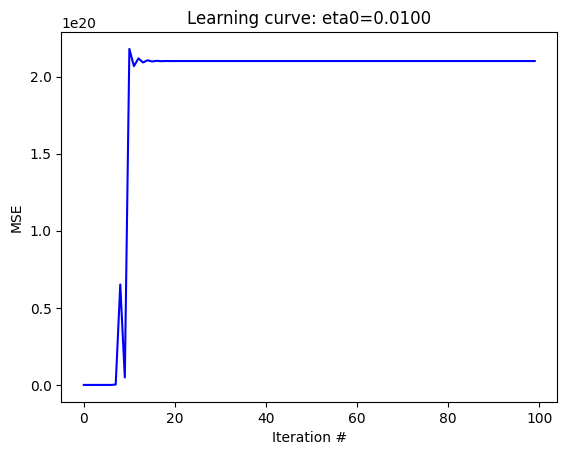

In [12]:

eta0 = 1e-2

sgd_pipeline = Pipeline([
    ("std_scaler" , StandardScaler()),
    ("regressor" , SGDRegressor(
        max_iter=1,
        tol=None,
        eta0=eta0,
        warm_start=True,
        random_state=42
    ))
])


loss = []

for epoch in range(1,101):
    sgd_pipeline.fit(feature_train , label_train)
    pred_train = sgd_pipeline.predict(feature_train)
    loss_train = mean_squared_error(label_train , pred_train)
    loss.append(loss_train)


# Plot
plt.plot(np.arange(len(loss)), loss, 'b-')

plt.xlabel("Iteration #")
plt.ylabel("MSE")
plt.title(f"Learning curve: eta0={eta0:.4f}")

plt.show()